In [1]:
# Ячейка № 1

# подключение используемых библиотек

# подключение библиотеки numpy
import numpy as np

# подключение функций fft, fftfreq
from scipy.fft import fft, fftfreq

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

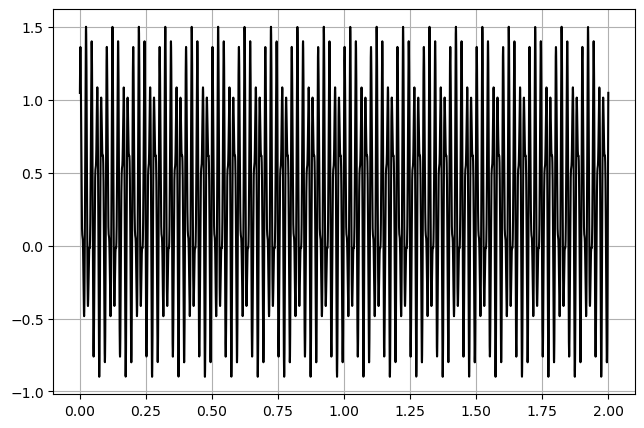

In [2]:
# Ячейка № 2

# вычисление и визуализация визуализация значений ДС

# задание числа отсчетов дискретного сигнала
N = 8192

# задание значений левой и правой границ
# временного интервала,
# на котором вычисляются значения дискретного сигнала
T1 = 0
T2 = 2

# вычисление координат узлов временной сетки
t = np.linspace(T1, T2, N)

# задание постоянной составляющей анализируемого сигнала
Level = 0.3

# задание параметров первой периодической составляющей
# анализируемого сигнала
A1 = 0.8  # амплитуда
Freq1 = 50  # частота
Phi1 = np.pi / 6  # начальная фаза

# задание параметров второй периодической составляющей
# анализируемого сигнала
A2 = 0.4  # амплитуда
Freq2 = 90  # частота
Phi2 = np.pi / 3  # начальная фаза

# инициализация массив u,
# используемого для хранения отсчетов
# анализируемого сигнала
u = np.zeros(N)

# вычисление значений анализируемого сигнала
# в узлах используемой временной сетки
u = (
    Level
    + A1 * np.sin(2 * np.pi * Freq1 * t + Phi1)
    + A2 * np.sin(2 * np.pi * Freq2 * t + Phi2)
)

# визуализация анализируемого сигнала
# подключение пакета matplotlib.pyplot

fig = plt.figure(figsize=(7.5, 5))
ax = fig.add_subplot()
plt.plot(t, u, color="black")
ax.grid(True)
plt.show()

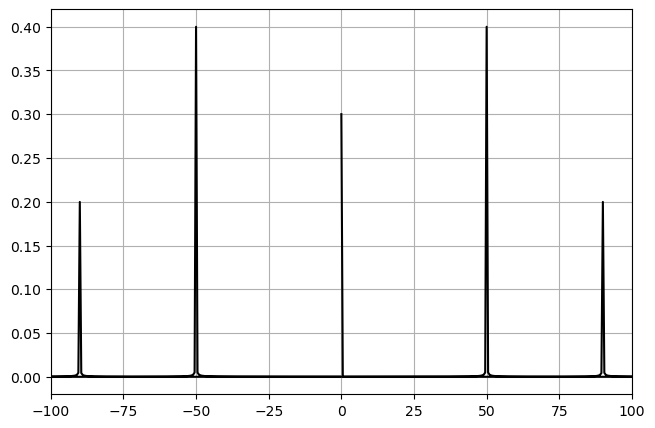

In [ ]:
# Ячейка № 3

# вычисление и визуализация
# коэффициентов ДПФ

# определение шага временной сетки,
# в узлах которой вычислены значения
# анализируемого сигнала
dt = t[1] - t[0]

# вычисление значений комплекснозначных
# коэффициентов ряда Фурье
c = fft(u)

# вычисление соответствующих значений
# частот спектральных гармоник
Freq = fftfreq(N, dt)

# визуализация результатов вычисления
# ДПФ изучаемого сигнала
fig = plt.figure(figsize=(7.5, 5))
ax = fig.add_subplot()
plt.plot(Freq, np.abs(c) / N, color="black")
# plt.plot(Freq,np.abs(c)/N,'o')
plt.xlim([-100, 100])
plt.grid(True)
plt.show()


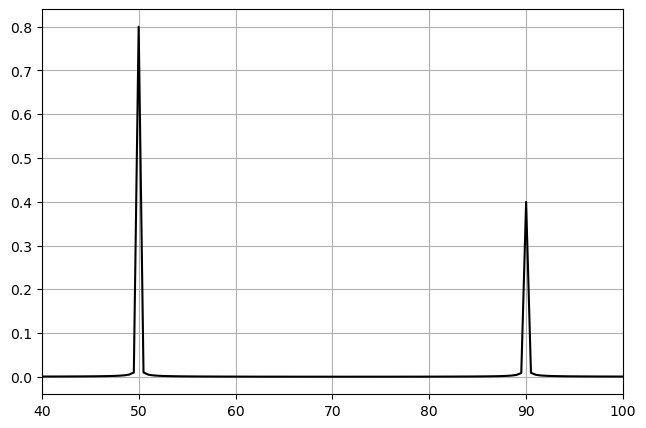

In [ ]:
# Ячейка № 4

# визуализация информативной части спектра

# задание числа информативных спектральных гармоник
N2 = round(N / 2) - 1

# инициализация массивов, используемых для хранения
# значений частот информативных спектральных гармоник
# и соответствующих нормированных амплитуд
c_R = np.zeros(N2)
Freq_R = np.zeros(N2)

# размещение в массивах Freq_R и c_R
# значений частот информативных спектральных гармоник
# и соответствующих нормированных амплитуд
for i in range(N2):
    Freq_R[i] = Freq[i + 1]
    c_R[i] = np.abs(c[i + 1]) / N

# визуализация информативной
# части амплитудного спектра
# изучаемого сигнала
fig = plt.figure(figsize=(7.5, 5))
ax = fig.add_subplot()
plt.plot(Freq_R, 2 * c_R, color="black")
plt.xlim([40, 100])
plt.grid(True)
plt.show()